In [1]:
!pip install librosa scikit-learn matplotlib numpy


[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import pickle
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import pickle

In [2]:
from mfcc_api import MFCCExtractor

In [5]:
file_path = "../saron_p1.wav"
y, sr = librosa.load(file_path, sr=None)
print(f"Loaded {file_path} with sample rate {sr} and {len(y)} samples.")

Loaded ../saron_p1.wav with sample rate 44100 and 309022 samples.


In [ ]:
extractor = MFCCExtractor(sr = sr)
mfccs = extractor.extract(y)

MFCC plot saved to mfcc_saron_p1.png


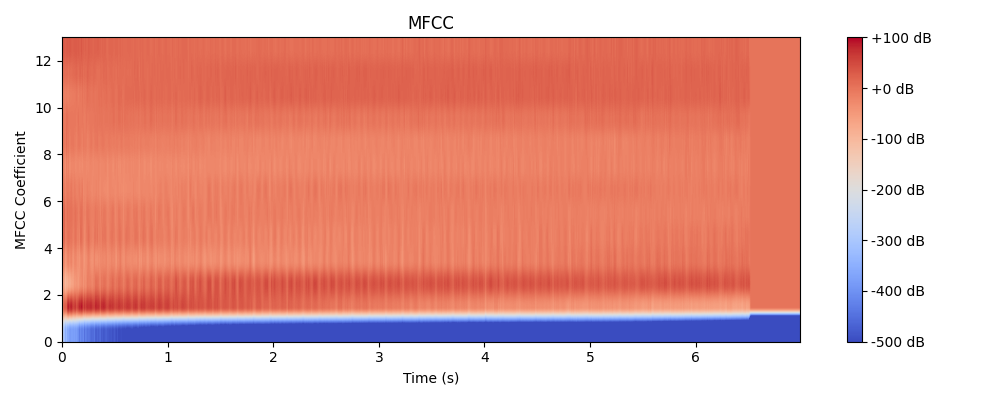

In [11]:
plot_file = f"mfcc_{os.path.basename(file_path).split('.')[0]}.png"
extractor.save_plot(mfccs, plot_file)
print(f"MFCC plot saved to {plot_file}")
from IPython.display import Image, display
display(Image(filename=plot_file))

In [12]:
n_components = 8
gmm = GaussianMixture(n_components=n_components, covariance_type='diag', random_state=42)
gmm.fit(mfccs)
print(f"GMM trained with {n_components} components.")

GMM trained with 8 components.


In [14]:
model_name="gmm_saron_p1"
model_file=f"{model_name}.pkl"
with open(model_file, 'wb') as f:
    pickle.dump({
        "gmm": gmm,
        "sr": sr,
        "mfcc_params":{
            "num_ceps":extractor.num_ceps,
            "nfilt": extractor.nfilt,
            # "nfft": extractor.nfft,
            "frame_size": extractor.frame_size,
            "frame_stride": extractor.frame_stride,
            "pre_emphasis": extractor.pre_emphasis
        }
    }, f)
print(f"GMM model saved to {model_file}")

GMM model saved to gmm_saron_p1.pkl


In [ ]:
with open("models/gmm_saron_p1.pkl", "rb") as f:
    loaded_data = pickle.load(f)
print(loaded_data.keys())

# NEW

In [6]:
# retrain_gmm.ipynb

import os
from pathlib import Path
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from app.services.mfcc_service import extract_mfcc_from_file  # panggil API MFCC lokal
from coret.gmm_service import GMMDiag  # pastikan import sesuai

# --------------- CONFIG ----------------
MODEL_DIR = Path("app/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Daftar model saron
models = ["saron_p1", "saron_p2", "saron_p3", "saron_p4", "saron_p5", "saron_p6", "saron_p7"]

# Folder dataset
DATASET_DIR = Path("datasets")  # misal tiap folder ada saron_p1, saron_p2, dst

# ---------------- TRAINING ----------------
for model_name in models:
    print(f"🟢 Training model: {model_name}")

    model_path = DATASET_DIR / model_name
    if not model_path.exists():
        print(f"⚠️ Folder dataset {model_path} tidak ditemukan. Skip.")
        continue

    mfcc_list = []
    for file in model_path.glob("*.wav"):
        try:
            mfcc = extract_mfcc_from_file(str(file))
            mfcc_list.append(mfcc)
        except Exception as e:
            print(f"❌ Gagal ekstrak {file.name}: {e}")

    if not mfcc_list:
        print(f"⚠️ Tidak ada MFCC untuk {model_name}. Skip.")
        continue

    # Gabungkan semua frame
    X = np.vstack(mfcc_list)
    print(f"   Total frames: {X.shape[0]} | Features: {X.shape[1]}")

    # Standardisasi
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X)

    # Fit GMM
    gmm = GMMDiag(n_components=8, reg_covar=1e-3, max_iter=200, tol=1e-4)
    gmm.fit(Xs)

    # Statistik
    per_frame = gmm.score_samples(Xs)
    train_mean = float(np.mean(per_frame))
    train_std = float(np.std(per_frame))
    threshold = train_mean - 2.0 * train_std
    stats = {"train_mean": train_mean, "train_std": train_std, "threshold": threshold, "per_frame_train": per_frame}

    # Simpan model
    obj = {"gmm": gmm, "scaler": scaler, "stats": stats}
    joblib.dump(obj, MODEL_DIR / f"{model_name}.joblib")
    print(f"✅ Model saved: {MODEL_DIR / f'{model_name}.joblib'}\n")


🟢 Training model: saron_p1
   Total frames: 700 | Features: 13
✅ Model saved: app\models\saron_p1.joblib

🟢 Training model: saron_p2
   Total frames: 637 | Features: 13
✅ Model saved: app\models\saron_p2.joblib

🟢 Training model: saron_p3
   Total frames: 781 | Features: 13
✅ Model saved: app\models\saron_p3.joblib

🟢 Training model: saron_p4
   Total frames: 825 | Features: 13
✅ Model saved: app\models\saron_p4.joblib

🟢 Training model: saron_p5
   Total frames: 709 | Features: 13
✅ Model saved: app\models\saron_p5.joblib

🟢 Training model: saron_p6
   Total frames: 730 | Features: 13
✅ Model saved: app\models\saron_p6.joblib

🟢 Training model: saron_p7
   Total frames: 721 | Features: 13
✅ Model saved: app\models\saron_p7.joblib

